# Regression Machine Learning Case Study Project

## 1. Định nghĩa vấn đề (Define Problem)

Bộ dữ liệu này được giới thiệu trong bài báo nổi tiếng của  
**David Harrison** và **Daniel L. Rubinfeld** (1978).
* **Mô tả**
    - Bộ dữ liệu bao gồm các thông tin về giá nhà tại khu vực Boston (Mỹ) và các yếu tố kinh tế – xã hội ảnh hưởng đến giá nhà.
    - Có tổng cộng **506 mẫu**.
    - Bao gồm **13 biến đầu vào (features)** và **1 biến mục tiêu (target)**.

* **Dữ liệu vào (Features - X)**
    1. **CRIM**: Tỷ lệ tội phạm bình quân đầu người theo từng thị trấn.  
    2. **ZN**: Tỷ lệ diện tích đất ở được quy hoạch cho các lô đất lớn hơn 25.000 foot vuông (%).  
    3. **INDUS**: Tỷ lệ diện tích đất dành cho khu công nghiệp (không bán lẻ) theo từng thị trấn (%).  
    4. **CHAS**: Biến giả liên quan đến sông Charles  
        - = 1 nếu khu vực giáp sông  
        - = 0 nếu không  
    5. **NOX**: Nồng độ khí oxit nitơ (phần trên 10 triệu).  
    6. **RM**: Số phòng trung bình trên mỗi căn nhà.  
    7. **AGE**: Tỷ lệ các căn nhà do chủ sở hữu ở được xây trước năm 1940 (%).  
    8. **DIS**: Khoảng cách có trọng số đến 5 trung tâm việc làm của Boston.  
    9. **RAD**: Chỉ số mức độ tiếp cận các tuyến cao tốc hướng tâm.  
    10. **TAX**: Thuế tài sản tính theo giá trị đầy đủ (USD trên mỗi 10.000 USD giá trị tài sản).  
    11. **PTRATIO**: Tỷ lệ học sinh trên giáo viên theo từng thị trấn.  
    12. **B**: $B = 1000(B_k - 0.63)^2$ .Trong đó \( B_k \) là tỷ lệ người da đen theo từng thị trấn.  
    13. **LSTAT**: Phần trăm dân số thuộc tầng lớp có địa vị kinh tế – xã hội thấp (%).
* **Biến mục tiêu (Target - y)**
    - **MEDV**: Giá trị trung vị của các căn nhà do chủ sở hữu ở  
    - Đơn vị: **nghìn đô la Mỹ (1000 USD)**

## 2. Chuẩn bị dữ liệu (Prepare Problem)

### 2.1. Import các thư viện (Load libaries)

In [3]:
# Load libraries
import numpy
from IPython import display
from numpy import arange
from matplotlib import pyplot
from pandas import read_csv
from pandas import set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error

### 2.2. Nhập dữ liệu (Load dataset)


In [14]:
file_name = "BostonHousing.csv"
names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
dataset = read_csv(file_name, sep=",", names = names, header=0)
display.display(dataset)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,6.32e-03,18.0,2.31,0,0.54,6.58,65.2,4.09,1,296,15.3,396.90,4.98,24.0
1,2.73e-02,0.0,7.07,0,0.47,6.42,78.9,4.97,2,242,17.8,396.90,9.14,21.6
2,2.73e-02,0.0,7.07,0,0.47,7.18,61.1,4.97,2,242,17.8,392.83,4.03,34.7
3,3.24e-02,0.0,2.18,0,0.46,7.00,45.8,6.06,3,222,18.7,394.63,2.94,33.4
4,6.91e-02,0.0,2.18,0,0.46,7.15,54.2,6.06,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,6.26e-02,0.0,11.93,0,0.57,6.59,69.1,2.48,1,273,21.0,391.99,9.67,22.4
502,4.53e-02,0.0,11.93,0,0.57,6.12,76.7,2.29,1,273,21.0,396.90,9.08,20.6
503,6.08e-02,0.0,11.93,0,0.57,6.98,91.0,2.17,1,273,21.0,396.90,5.64,23.9
504,1.10e-01,0.0,11.93,0,0.57,6.79,89.3,2.39,1,273,21.0,393.45,6.48,22.0


## 3. Phân tích dữ liệu (Analyze Data)


### 3.1. Thống kê mô tả (Descriptive Statistics)
#### (1) **Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Mô tả và thông tin chung về dữ liệu

In [15]:
#shape
print("\nDataset shape: ")
print(dataset.shape)



Dataset shape: 
(506, 14)


In [27]:
# types
print("\nDataset types: ")
display.display(dataset.dtypes)


Dataset types: 


CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

In [17]:
#head
print("\nDataset (10 rows): ")
display.display(dataset.head(5))
display.display(dataset.tail(5))


Dataset (10 rows): 


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,6.32e-03,18.0,2.31,0,0.54,6.58,65.2,4.09,1,296,15.3,396.90,4.98,24.0
1,2.73e-02,0.0,7.07,0,0.47,6.42,78.9,4.97,2,242,17.8,396.90,9.14,21.6
2,2.73e-02,0.0,7.07,0,0.47,7.18,61.1,4.97,2,242,17.8,392.83,4.03,34.7
3,3.24e-02,0.0,2.18,0,0.46,7.00,45.8,6.06,3,222,18.7,394.63,2.94,33.4
4,6.91e-02,0.0,2.18,0,0.46,7.15,54.2,6.06,3,222,18.7,396.90,5.33,36.2


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06,0.0,11.93,0,0.57,6.59,69.1,2.48,1,273,21.0,391.99,9.67,22.4
502,0.05,0.0,11.93,0,0.57,6.12,76.7,2.29,1,273,21.0,396.90,9.08,20.6
503,0.06,0.0,11.93,0,0.57,6.98,91.0,2.17,1,273,21.0,396.90,5.64,23.9
504,0.11,0.0,11.93,0,0.57,6.79,89.3,2.39,1,273,21.0,393.45,6.48,22.0
505,0.05,0.0,11.93,0,0.57,6.03,80.8,2.50,1,273,21.0,396.90,7.88,11.9


In [34]:
# Ma trận tương quan hệ số
set_option('display.precision', 2)
display.display(dataset.corr(method='pearson')) 
## Hệ số tương quan Pearson giữa các biến
# -1  →  quan hệ tuyến tính âm hoàn hảo 
#  0  →  không có quan hệ tuyến tính
# +1  →  quan hệ tuyến tính dương hoàn hảo
#(và abs >= 0,4 là tương quan trung bình và mạnh)
dataset.info()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.00,-0.20,0.41,-5.59e-02,0.42,-0.22,0.35,-0.38,6.26e-01,0.58,0.29,-0.39,0.46,-0.39
ZN,-0.20,1.00,-0.53,-4.27e-02,-0.52,0.31,-0.57,0.66,-3.12e-01,-0.31,-0.39,0.18,-0.41,0.36
INDUS,0.41,-0.53,1.00,6.29e-02,0.76,-0.39,0.64,-0.71,5.95e-01,0.72,0.38,-0.36,0.60,-0.48
CHAS,-0.06,-0.04,0.06,1.00e+00,0.09,0.09,0.09,-0.10,-7.37e-03,-0.04,-0.12,0.05,-0.05,0.18
NOX,0.42,-0.52,0.76,9.12e-02,1.00,-0.30,0.73,-0.77,6.11e-01,0.67,0.19,-0.38,0.59,-0.43
RM,-0.22,0.31,-0.39,9.13e-02,-0.30,1.00,-0.24,0.21,-2.10e-01,-0.29,-0.36,0.13,-0.61,0.70
AGE,0.35,-0.57,0.64,8.65e-02,0.73,-0.24,1.00,-0.75,4.56e-01,0.51,0.26,-0.27,0.60,-0.38
DIS,-0.38,0.66,-0.71,-9.92e-02,-0.77,0.21,-0.75,1.00,-4.95e-01,-0.53,-0.23,0.29,-0.50,0.25
RAD,0.63,-0.31,0.60,-7.37e-03,0.61,-0.21,0.46,-0.49,1.00e+00,0.91,0.46,-0.44,0.49,-0.38
TAX,0.58,-0.31,0.72,-3.56e-02,0.67,-0.29,0.51,-0.53,9.10e-01,1.00,0.46,-0.44,0.54,-0.47


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


**Nhận xét:**
* Bộ dữ liệu gồm 13 thuộc tính đặc trưng ảnh hưởng đến giá nhà ở Boston
* Các tính chất có các đơn vị không đồng nhất
* Tổng số dòng dữ liệu là 506
* Dữ liệu không có giá triị thiếu
* Các giá trị trung vị MEDV luôn bị chặn trên ở 50%, biến CHAS là biến nhị phân (Chỉ 0 và 1)

#### (2) **Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị NaN không? Hiển thị dòng bị vi phạm.

In [46]:
has_null = dataset.isnull().sum().any()
has_nan = dataset.isna().sum().any()
n_duplicated = dataset.duplicated().sum().any()
print(f'Tính toàn vẹn dữ liệu:')
print(f'+ Có giá trị Null: {has_null}')
if has_null:
    display.display(dataset[dataset.isnull().any(axis=1)])
print(f'+ Có giá trị Nan: {has_nan}')
if has_nan:
    display.display(dataset[dataset.isna().any(axis=1)])
print(f'+ Số dòng trùng: {n_duplicated}')

Tính toàn vẹn dữ liệu:
+ Có giá trị Null: False
+ Có giá trị Nan: False
+ Số dòng trùng: False


**Nhận xét:** Nhận thấy dữ liệu không tồn tại giá trị Null, Nan và không có dòng trùng lặp

#### (3) **Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [50]:
# descriptions
set_option('display.precision', 1)
display.display(dataset.describe().T)

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.6e+00,8.6,6.3e-03,8.2e-02,0.3,3.7,89.0
ZN,506.0,1.1e+01,23.3,0.0e+00,0.0e+00,0.0,12.5,100.0
INDUS,506.0,1.1e+01,6.9,4.6e-01,5.2e+00,9.7,18.1,27.7
CHAS,506.0,6.9e-02,0.3,0.0e+00,0.0e+00,0.0,0.0,1.0
NOX,506.0,5.5e-01,0.1,3.9e-01,4.5e-01,0.5,0.6,0.9
RM,506.0,6.3e+00,0.7,3.6e+00,5.9e+00,6.2,6.6,8.8
AGE,506.0,6.9e+01,28.1,2.9e+00,4.5e+01,77.5,94.1,100.0
DIS,506.0,3.8e+00,2.1,1.1e+00,2.1e+00,3.2,5.2,12.1
RAD,506.0,9.5e+00,8.7,1.0e+00,4.0e+00,5.0,24.0,24.0
TAX,506.0,4.1e+02,168.5,1.9e+02,2.8e+02,330.0,666.0,711.0


## 4 Data Visualizations

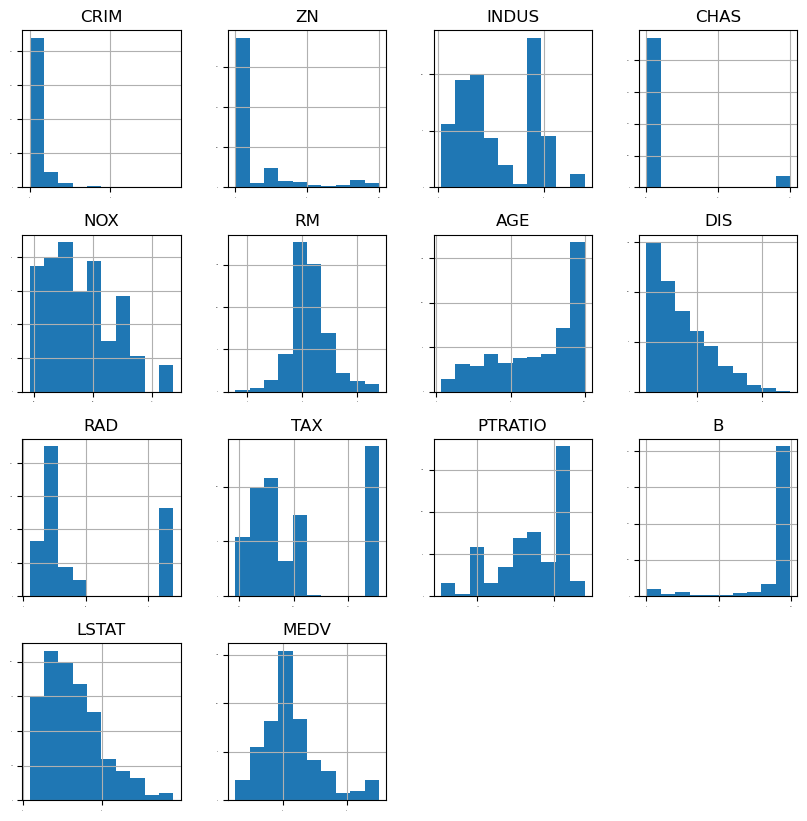

In [47]:
#Histogram
dataset.hist(sharex=False, sharey=False, xlabelsize=1, ylabelsize=1, figsize=(10,10))
pyplot.show()

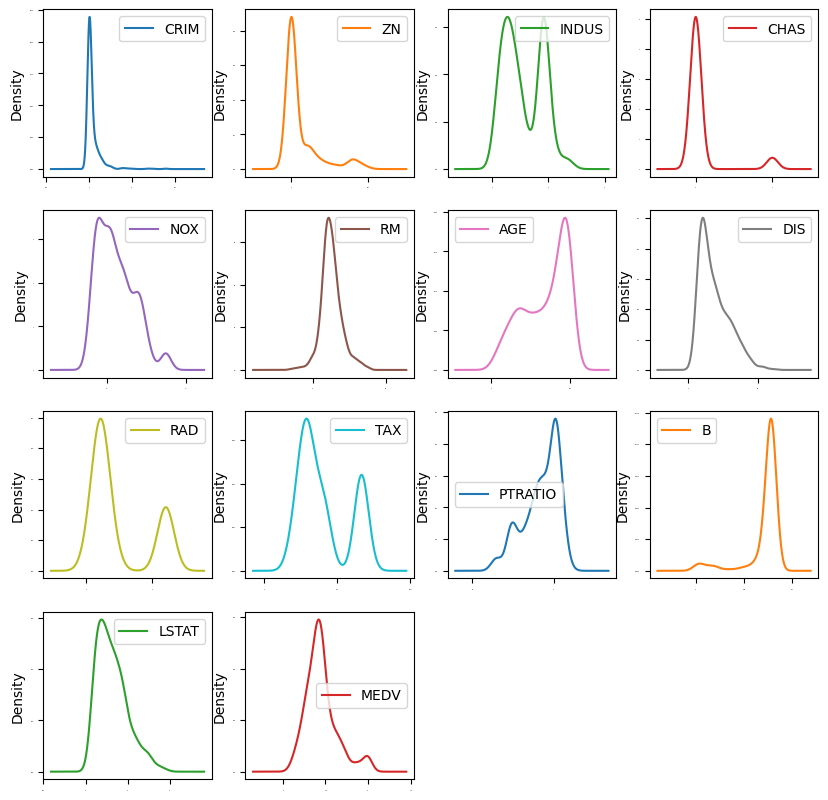

In [48]:
#density
dataset.plot(kind='density', subplots=True, layout=(4,4), sharex=False, sharey=False, fontsize=1, figsize=(10,10))
pyplot.show()

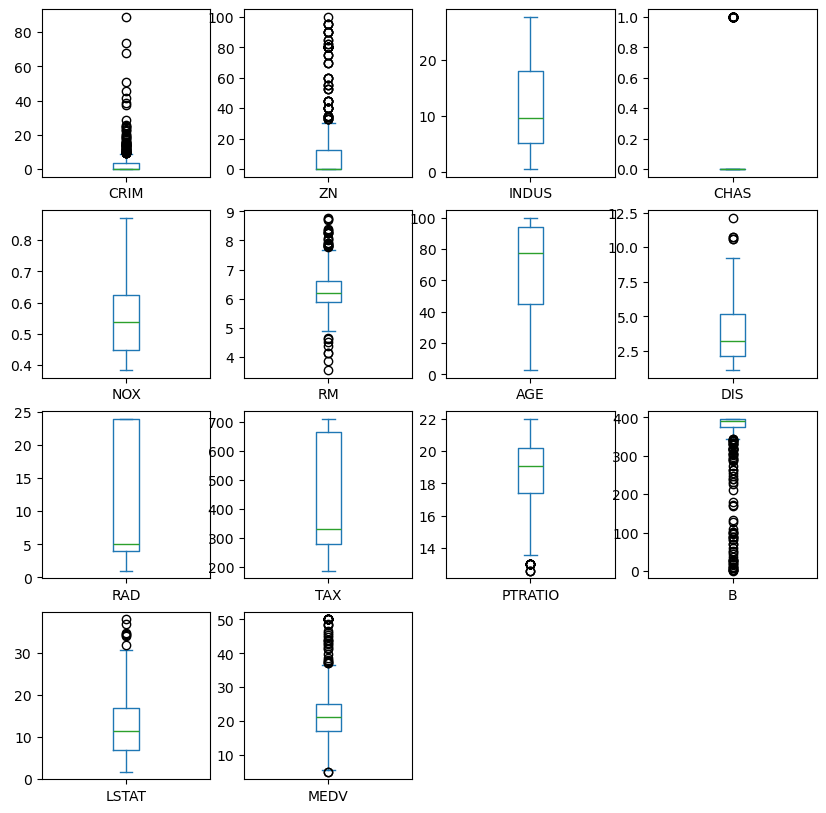

In [49]:
dataset.plot(kind='box',subplots=True, layout=(4,4),sharex=False, sharey=False, fontsize=10, figsize=(10,10))
pyplot.show()
# Median lệch khỏi trung tâm box --> Phân bố lệch
# Whisker dài một bên --> Lệch trái / phải
# Nhiều chấm ngoài --> Có nhiều điểm ngoại lệ
# Box cao --> Phương sai lớn

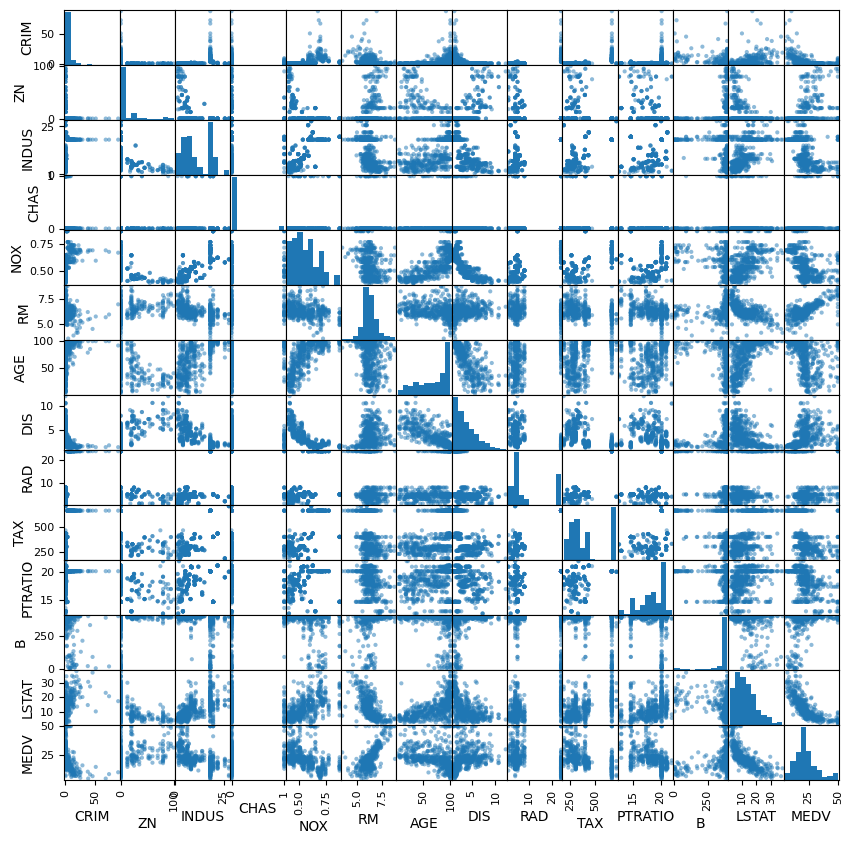

In [45]:
#SCATTER PLOT AND MATRIX
scatter_matrix(dataset, figsize=(10,10))
pyplot.show()

# Tụ lại theo hướng tăng/giảm --> Hai biến có tương quan tuyến tính dương/âm
# Rời rạc, không có xu hướng --> Hai biến không có tương quan tuyến tính rõ ràng